# Exponential Column Source Examples

**Scott Prahl**

**Mar 2026**

We use Green's function solutions for heat transfer caused by point illumination on the
surface of a semi-infinite absorbing medium, encapsulated within the `ExponentialColumnSource`
class.

`ExponentialColumnSource` models a vertical column of point sources beneath `(xp, yp)` whose
strength decays as `mu_a * exp(-mu_a z)`. It is the point-illumination analogue of
`ExponentialVolumeSource`: instead of uniform surface illumination, all deposited energy
originates from one surface point and then decays with depth.

The examples below show instantaneous, continuous, and pulsed solutions, together with the
supported `infinite`, `adiabatic`, and `zero` boundary conditions.

In [1]:
%config InlineBackend.figure_format = 'retina'

import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy

if sys.platform == "emscripten":
    import piplite

    await piplite.install("grheat", deps=False)

import grheat

## Instantaneous heating

### Infinite medium

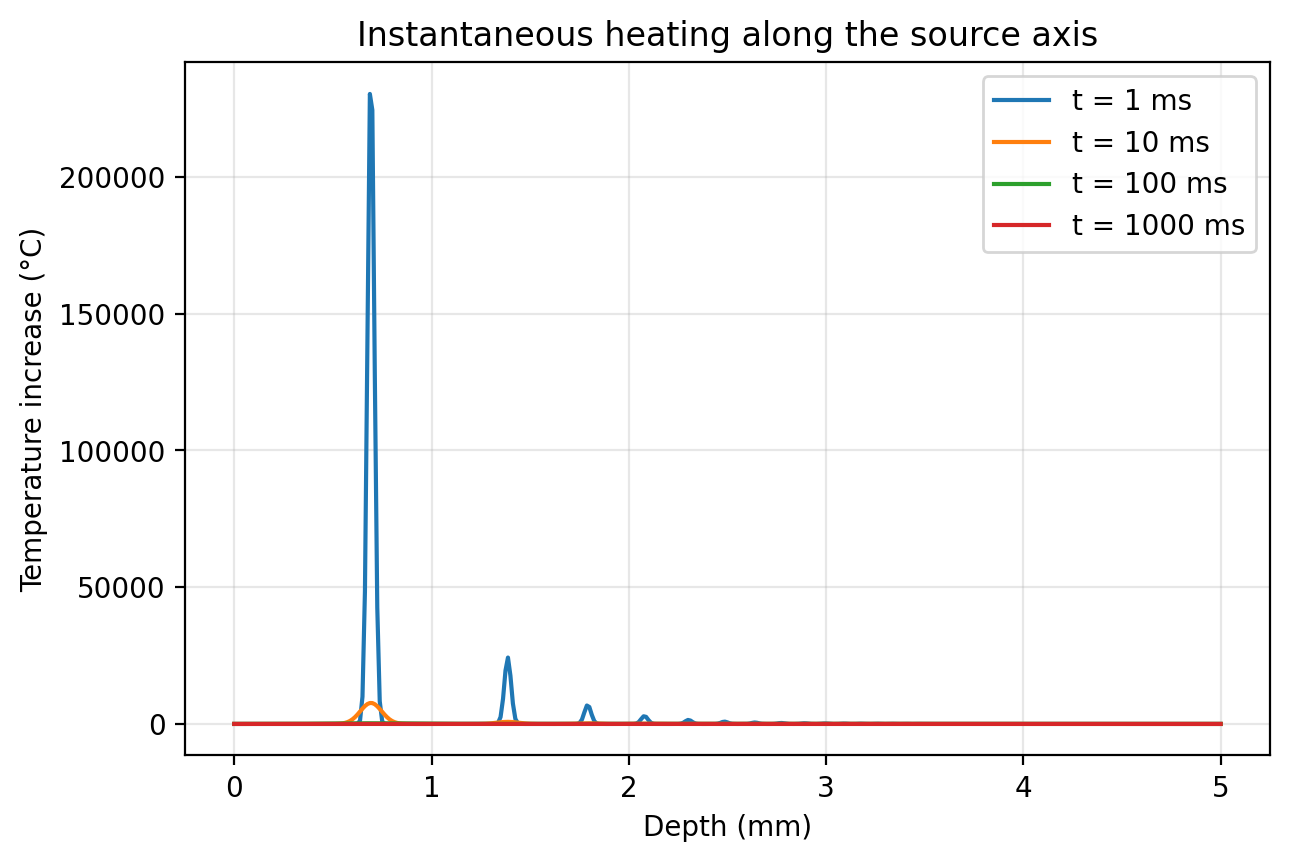

In [2]:
mu_a = 1 * 1000  # 1/m
source = grheat.ExponentialColumnSource(mu_a, xp=0, yp=0, boundary="infinite")
z = np.linspace(0, 0.005, 401)

plt.figure(figsize=(7, 4.5))
for t in [0.001, 0.01, 0.1, 1.0]:
    T = source.instantaneous(0, 0, z, t) * 1e6
    plt.plot(z * 1000, T, label=f"t = {1000 * t:.0f} ms")

plt.xlabel("Depth (mm)")
plt.ylabel("Temperature increase (°C)")
plt.title("Instantaneous heating along the source axis")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

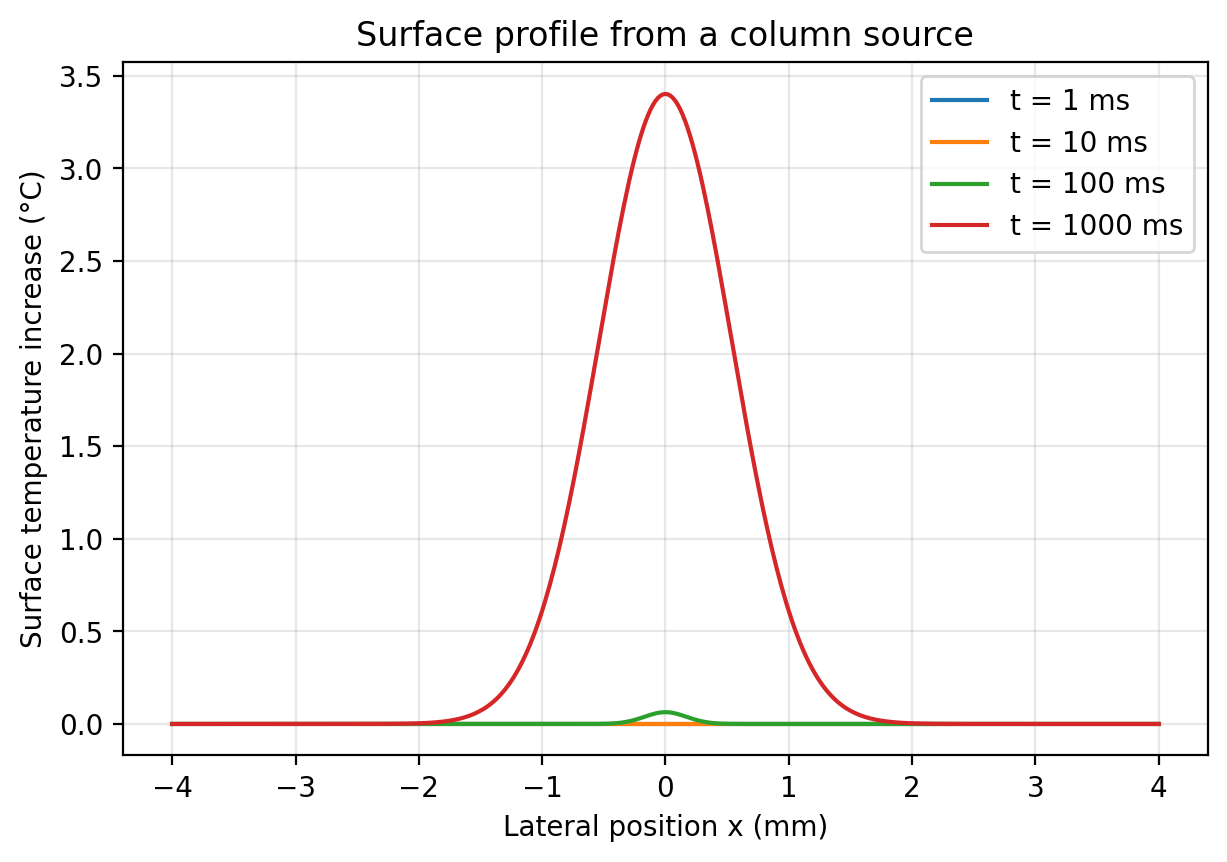

In [3]:
mu_a = 1 * 1000  # 1/m
source = grheat.ExponentialColumnSource(mu_a, xp=0, yp=0, boundary="infinite")
x = np.linspace(-0.004, 0.004, 401)

plt.figure(figsize=(7, 4.5))
for t in [0.001, 0.01, 0.1, 1.0]:
    T = source.instantaneous(x, 0, 0, t) * 1e6
    plt.plot(x * 1000, T, label=f"t = {1000 * t:.0f} ms")

plt.xlabel("Lateral position x (mm)")
plt.ylabel("Surface temperature increase (°C)")
plt.title("Surface profile from a column source")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

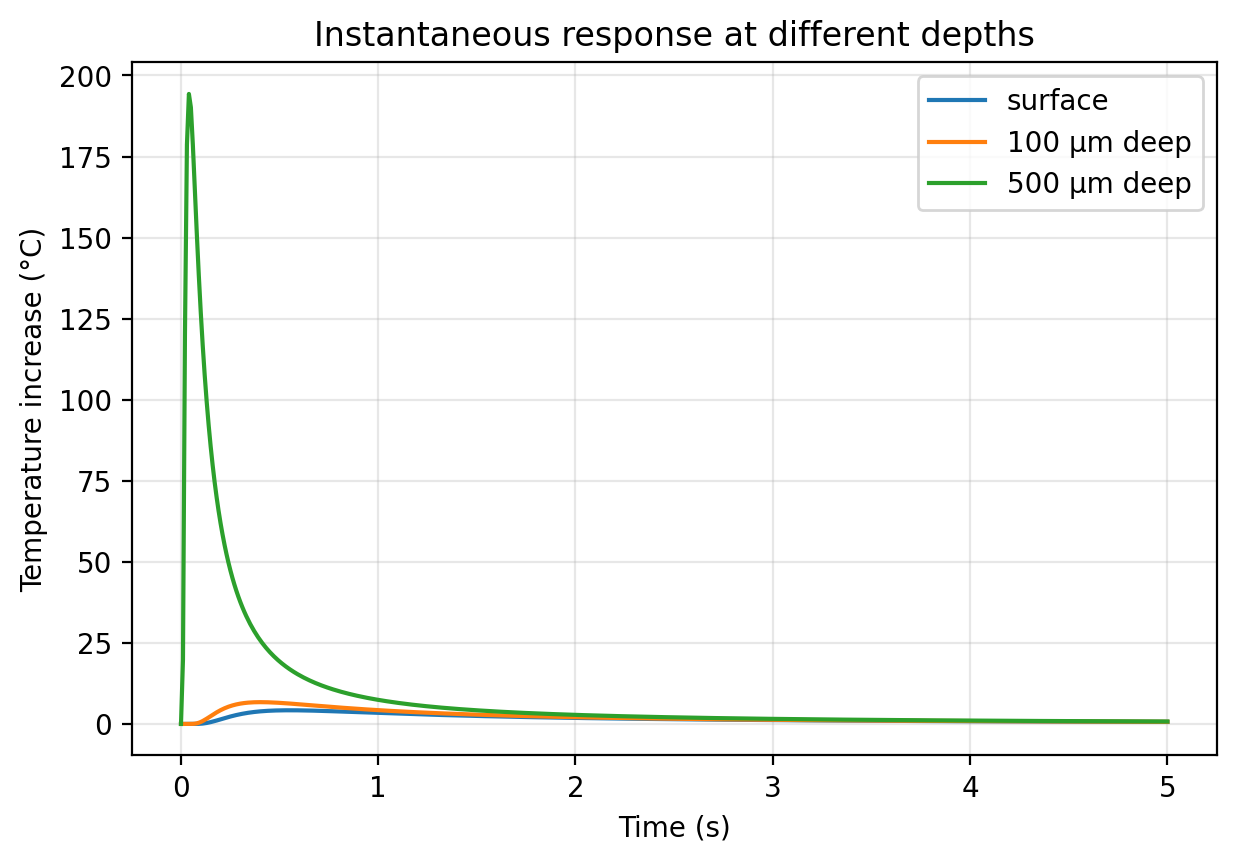

In [4]:
mu_a = 1 * 1000  # 1/m
source = grheat.ExponentialColumnSource(mu_a, xp=0, yp=0, boundary="infinite")
t = np.linspace(0.001, 5.0, 500)

plt.figure(figsize=(7, 4.5))
for z, label in [(0.0, "surface"), (0.0001, "100 µm deep"), (0.0005, "500 µm deep")]:
    T = source.instantaneous(0, 0, z, t) * 1e6
    plt.plot(t, T, label=label)

plt.xlabel("Time (s)")
plt.ylabel("Temperature increase (°C)")
plt.title("Instantaneous response at different depths")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Adiabatic surface condition

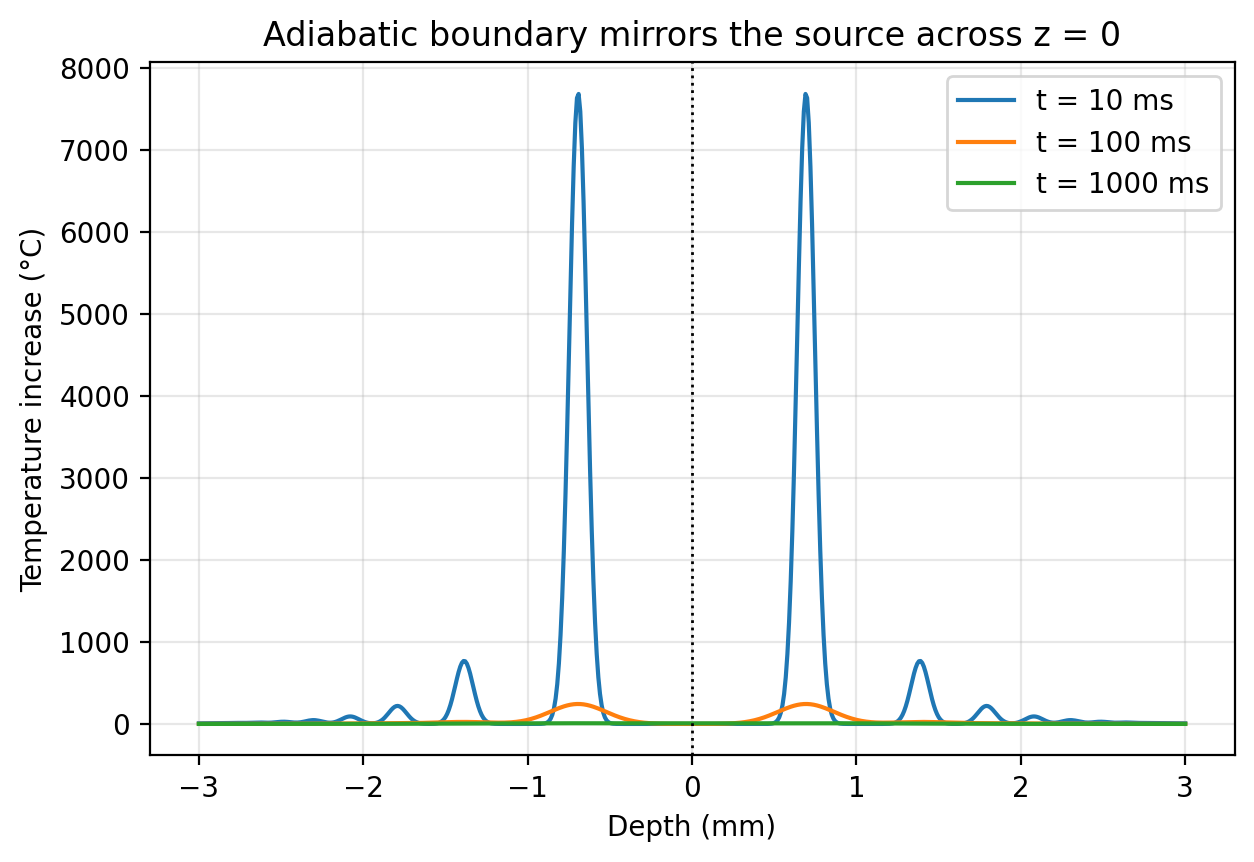

In [5]:
mu_a = 1 * 1000  # 1/m
source = grheat.ExponentialColumnSource(mu_a, xp=0, yp=0, boundary="adiabatic")
z = np.linspace(-0.003, 0.003, 601)

plt.figure(figsize=(7, 4.5))
for t in [0.01, 0.1, 1.0]:
    T = source.instantaneous(0, 0, z, t) * 1e6
    plt.plot(z * 1000, T, label=f"t = {1000 * t:.0f} ms")

plt.axvline(0, color="black", linestyle=":", linewidth=1)
plt.xlabel("Depth (mm)")
plt.ylabel("Temperature increase (°C)")
plt.title("Adiabatic boundary mirrors the source across z = 0")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Zero surface condition

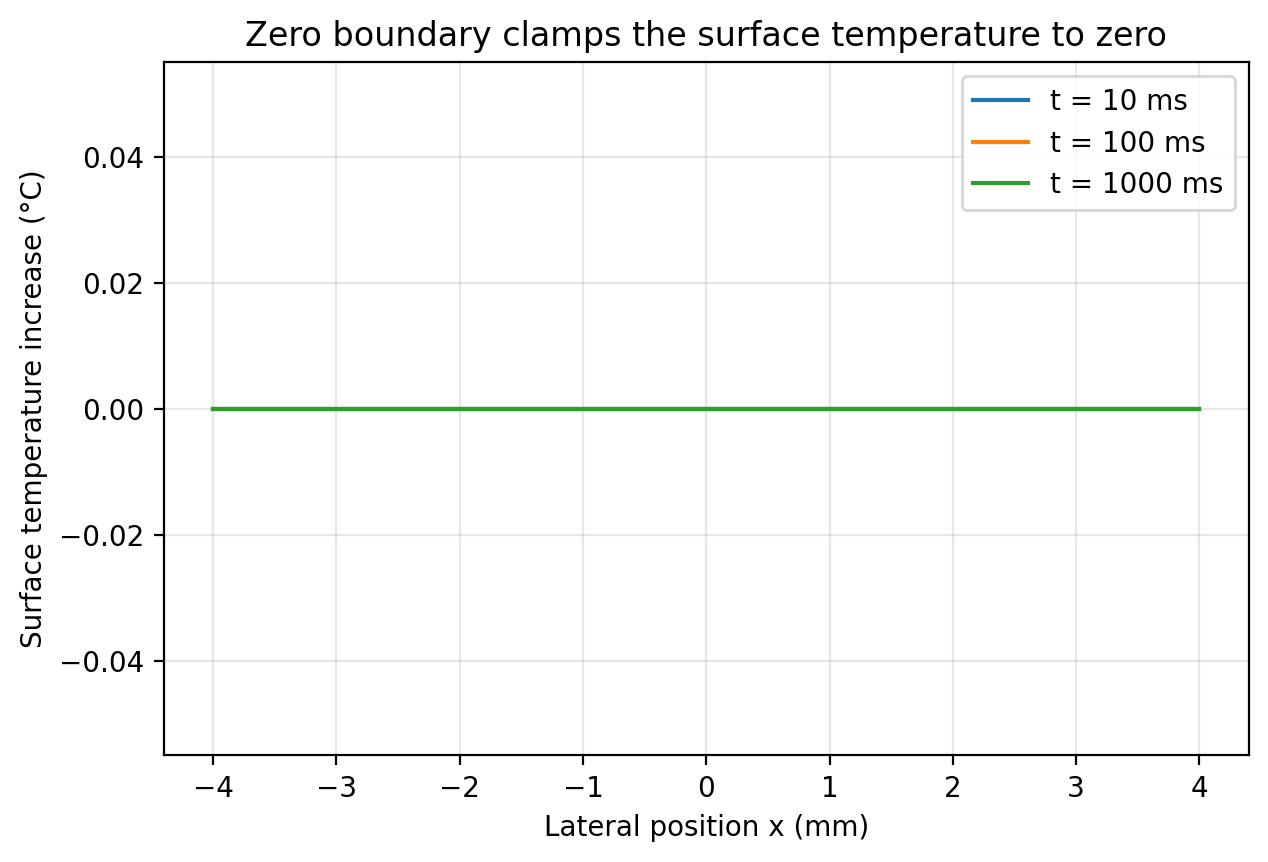

In [6]:
mu_a = 1 * 1000  # 1/m
source = grheat.ExponentialColumnSource(mu_a, xp=0, yp=0, boundary="zero")
x = np.linspace(-0.004, 0.004, 401)

plt.figure(figsize=(7, 4.5))
for t in [0.01, 0.1, 1.0]:
    T = source.instantaneous(x, 0, 0, t) * 1e6
    plt.plot(x * 1000, T, label=f"t = {1000 * t:.0f} ms")

plt.xlabel("Lateral position x (mm)")
plt.ylabel("Surface temperature increase (°C)")
plt.title("Zero boundary clamps the surface temperature to zero")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Continuous heating

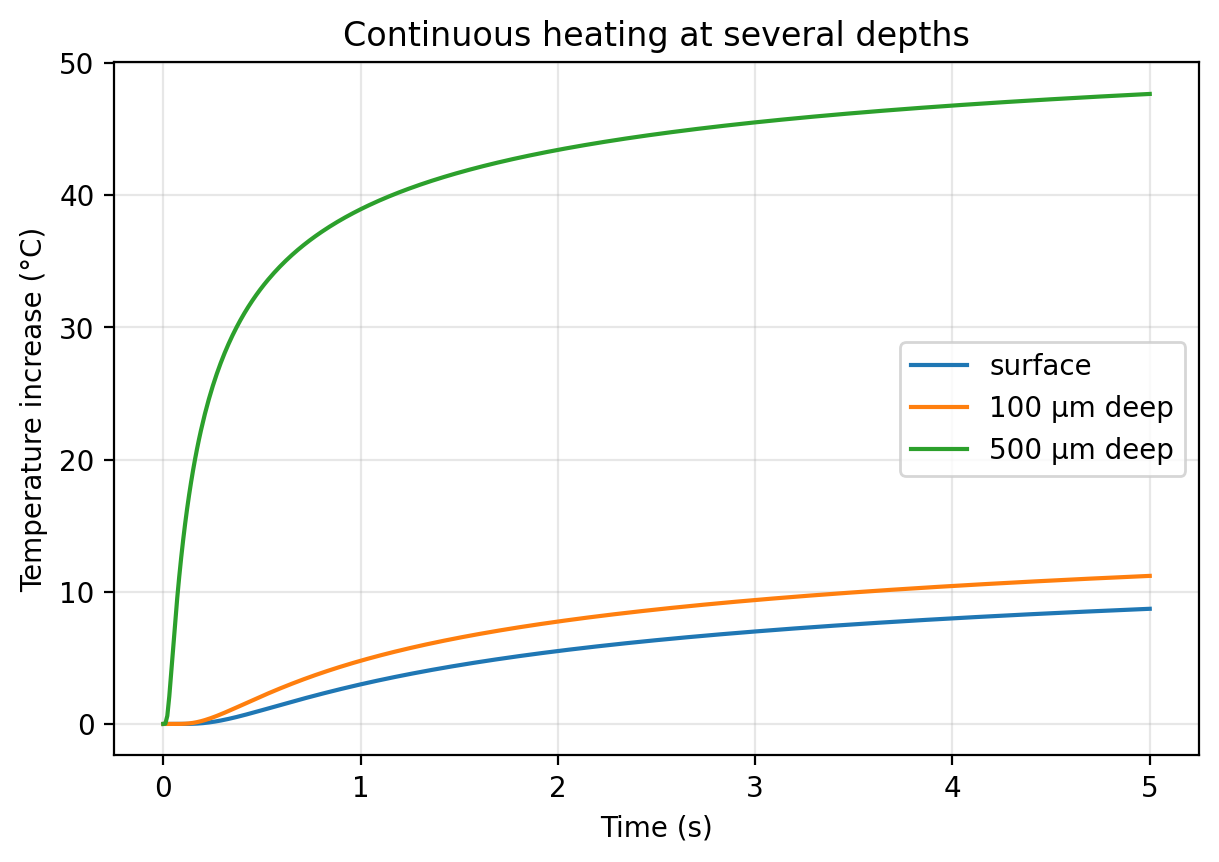

In [7]:
mu_a = 1 * 1000  # 1/m
source = grheat.ExponentialColumnSource(mu_a, xp=0, yp=0, boundary="infinite")
t = np.linspace(0, 5.0, 500)

plt.figure(figsize=(7, 4.5))
for z, label in [(0.0, "surface"), (0.0001, "100 µm deep"), (0.0005, "500 µm deep")]:
    T = source.continuous(0, 0, z, t) * 1e6
    plt.plot(t, T, label=label)

plt.xlabel("Time (s)")
plt.ylabel("Temperature increase (°C)")
plt.title("Continuous heating at several depths")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

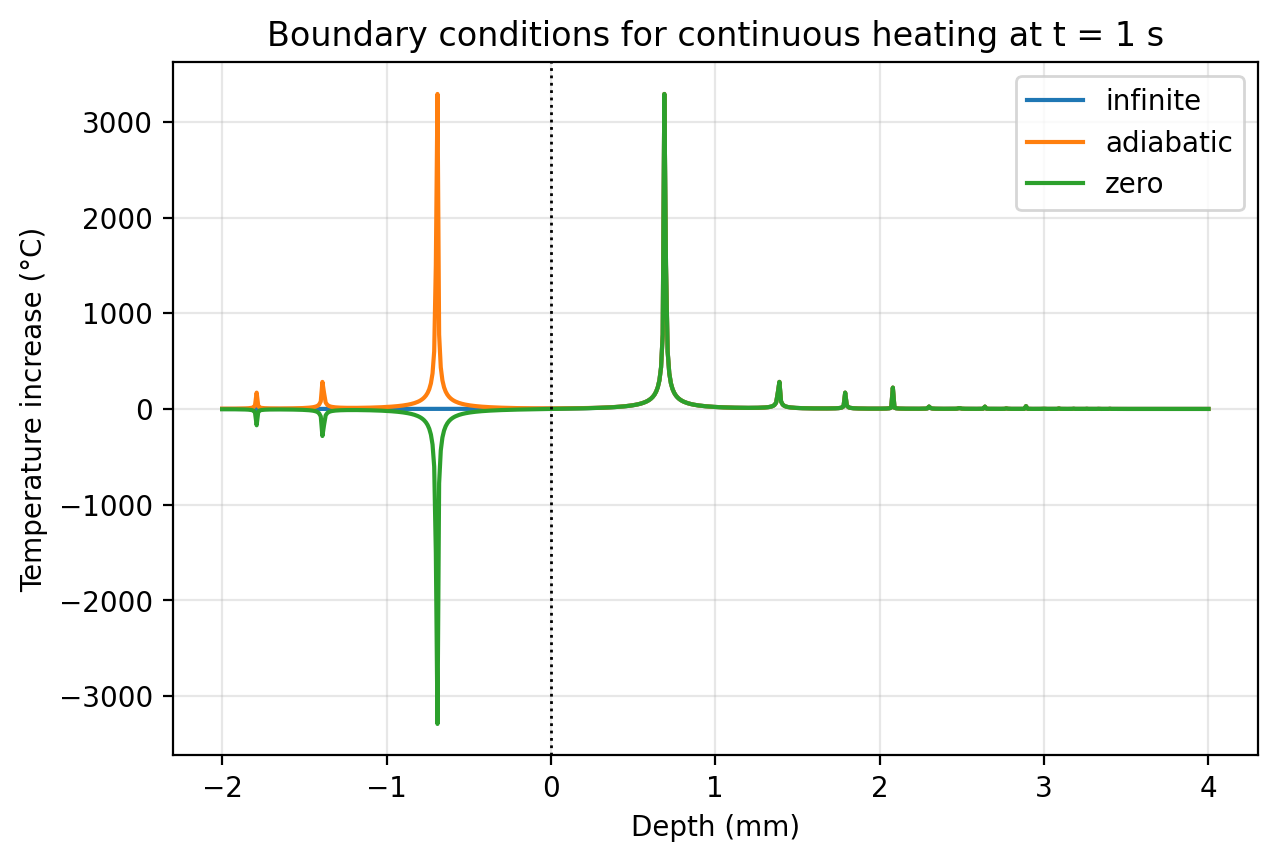

In [8]:
mu_a = 1 * 1000  # 1/m
z = np.linspace(-0.002, 0.004, 601)

plt.figure(figsize=(7, 4.5))
for boundary, label in [("infinite", "infinite"), ("adiabatic", "adiabatic"), ("zero", "zero")]:
    source = grheat.ExponentialColumnSource(mu_a, xp=0, yp=0, boundary=boundary)
    T = source.continuous(0, 0, z, 1.0) * 1e6
    plt.plot(z * 1000, T, label=label)

plt.axvline(0, color="black", linestyle=":", linewidth=1)
plt.xlabel("Depth (mm)")
plt.ylabel("Temperature increase (°C)")
plt.title("Boundary conditions for continuous heating at t = 1 s")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Pulsed heating

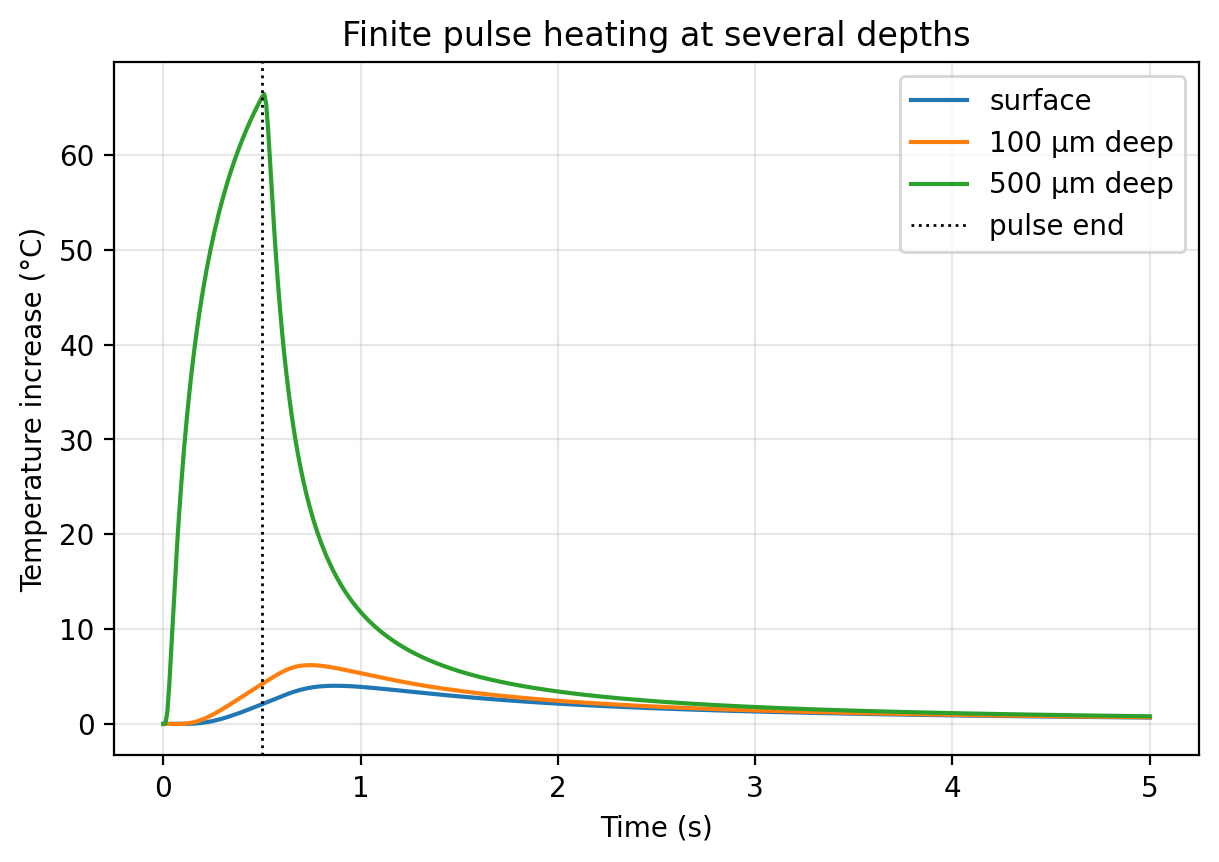

In [9]:
mu_a = 1 * 1000  # 1/m
source = grheat.ExponentialColumnSource(mu_a, xp=0, yp=0, boundary="infinite")
t = np.linspace(0, 5.0, 500)
t_pulse = 0.5

plt.figure(figsize=(7, 4.5))
for z, label in [(0.0, "surface"), (0.0001, "100 µm deep"), (0.0005, "500 µm deep")]:
    T = source.pulsed(0, 0, z, t, t_pulse) * 1e6
    plt.plot(t, T, label=label)

plt.axvline(t_pulse, color="black", linestyle=":", linewidth=1, label="pulse end")
plt.xlabel("Time (s)")
plt.ylabel("Temperature increase (°C)")
plt.title("Finite pulse heating at several depths")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

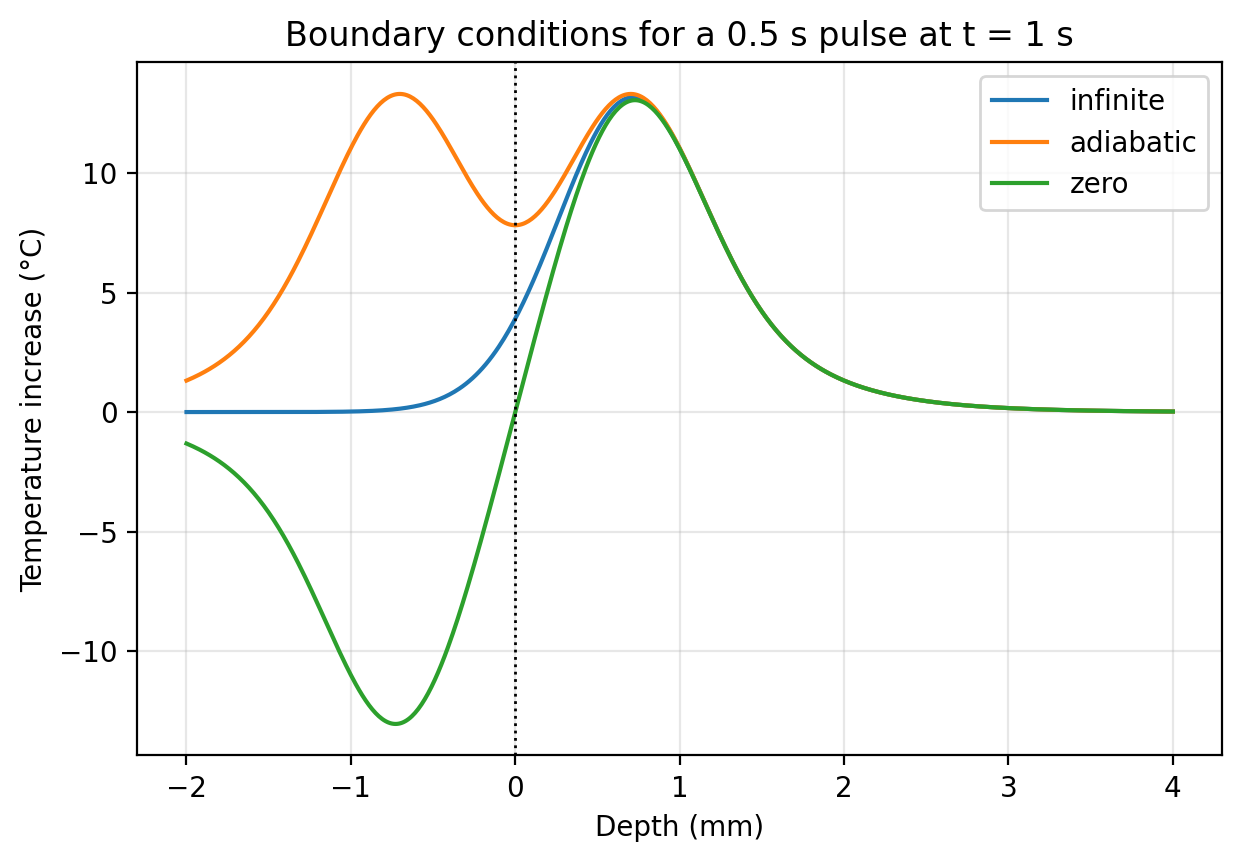

In [10]:
mu_a = 1 * 1000  # 1/m
z = np.linspace(-0.002, 0.004, 601)
t_pulse = 0.5

plt.figure(figsize=(7, 4.5))
for boundary, label in [("infinite", "infinite"), ("adiabatic", "adiabatic"), ("zero", "zero")]:
    source = grheat.ExponentialColumnSource(mu_a, xp=0, yp=0, boundary=boundary)
    T = source.pulsed(0, 0, z, 1.0, t_pulse) * 1e6
    plt.plot(z * 1000, T, label=label)

plt.axvline(0, color="black", linestyle=":", linewidth=1)
plt.xlabel("Depth (mm)")
plt.ylabel("Temperature increase (°C)")
plt.title("Boundary conditions for a 0.5 s pulse at t = 1 s")
plt.legend()
plt.grid(alpha=0.3)
plt.show()